# Adaptive Round-Up Prediction for Micro-Savings(Jomao)
### ML Framework for Behavior-Aware Round-Up Prediction | bKash · Nagad · Rocket

---

## Research Context

Bangladesh's MFS ecosystem processes hundreds of millions of transactions annually, yet no intelligent mechanism exists for converting everyday payments into automatic savings. This notebook builds a supervised regression model that predicts a **personalized, behavior-aware round-up amount** for each Make Payment transaction in real time.

$$\text{Round-Up Amount (Tk)} = f(\text{Transaction Amount, User Behavior, Financial State, Historical Patterns})$$



## Problem Statement  
Fixed round-up systems ignore user-specific behavioral and financial patterns.

There is no data-driven framework to answer:

> Given a user’s transaction amount, historical behavior, and financial state — what is the optimal round-up amount for this payment?



## Solution
A ml regression model that learns the interaction between transaction amount, income tier, intraday pressure signals, and historical spending patterns to predict an adaptive round-up that is both meaningful and fair.



## Research Significance  

This dataset enables:

- Personalized micro-savings prediction  
- Behavior-aware financial modeling  
- Real-time adaptive rounding systems  

It demonstrates that **round-up amounts can be learned from user behavior rather than fixed rules**, making micro-savings more efficient and user-friendly.


## Dataset
Synthetically generated structured transactional dataset designed for machine learning-based micro-savings prediction

---

## 1. Import Data and Required Packages

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split, KFold, cross_validate, GridSearchCV, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    HistGradientBoostingRegressor,
    AdaBoostRegressor
)

from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    r2_score
)

In [2]:
# setup configuration
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")
sns.set_theme(style="darkgrid")
plt.rcParams.update({
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8
})


RANDOM_STATE = 42
DATA_PATH = Path(
    r"roundup_data.csv"
)

In [3]:
df = pd.read_csv(DATA_PATH)

In [4]:
df.head()

,txn_id,user_id,timestamp,txn_amount,category,transaction_hour,is_weekend,hour_sin,hour_cos,txn_count_today,daily_total_spent,remaining_daily_capacity,txn_count_prev_7d,avg_spend_last_7days,spending_velocity_ratio,income_tier,user_tenure_days,is_new_user,pressure_score,monthly_savings_so_far,user_savings_streak,days_since_last_txn,clean_number_tier,rounded_amount,roundup_amount
0,TXN_00000001,USR_0001,2024-09-02 09:39:46,464,food_delivery,9,0,0.707,-0.707,1,0.000,600.000,0,450.000,1.031,Low,229,0,0.029,0,0,0,3,500,36
1,TXN_00000002,USR_0001,2024-09-02 13:53:43,460,ride_sharing,13,0,-0.259,-0.966,2,464.000,136.000,0,450.000,1.022,Low,229,0,0.888,36,0,0,3,500,40
2,TXN_00000003,USR_0001,2024-09-02 18:12:46,130,ride_sharing,18,0,-1.000,-0.000,3,924.000,-324.000,0,450.000,0.289,Low,229,0,0.950,76,0,0,3,150,20
3,TXN_00000004,USR_0001,2024-09-14 08:48:51,360,shopping,8,1,0.866,-0.500,1,0.000,600.000,0,450.000,0.800,Low,241,0,0.009,96,0,12,3,400,40
4,TXN_00000005,USR_0001,2024-09-14 13:16:36,692,ride_sharing,13,1,-0.259,-0.966,2,360.000,240.000,0,450.000,1.538,Low,241,0,0.710,136,0,0,3,750,58


In [5]:
print("DataFrame Shape: ", df.shape)

DataFrame Shape:  (24222, 25)


## 2. Exploratory Data Analysis (EDA)

In [6]:
# basic data overview
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24222 entries, 0 to 24221
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   txn_id                    24222 non-null  object 
 1   user_id                   24222 non-null  object 
 2   timestamp                 24222 non-null  object 
 3   txn_amount                24222 non-null  int64  
 4   category                  24222 non-null  object 
 5   transaction_hour          24222 non-null  int64  
 6   is_weekend                24222 non-null  int64  
 7   hour_sin                  24222 non-null  float64
 8   hour_cos                  24222 non-null  float64
 9   txn_count_today           24222 non-null  int64  
 10  daily_total_spent         24222 non-null  float64
 11  remaining_daily_capacity  24222 non-null  float64
 12  txn_count_prev_7d         24222 non-null  int64  
 13  avg_spend_last_7days      24222 non-null  float64
 14  spendi

In [7]:
TARGET_COL = "roundup_amount"
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

print("Target column: ", TARGET_COL)
print("\nNumerical columns: ", num_cols)
print("\nCategorical columns: ", cat_cols)

Target column:  roundup_amount

Numerical columns:  ['txn_amount', 'transaction_hour', 'is_weekend', 'hour_sin', 'hour_cos', 'txn_count_today', 'daily_total_spent', 'remaining_daily_capacity', 'txn_count_prev_7d', 'avg_spend_last_7days', 'spending_velocity_ratio', 'user_tenure_days', 'is_new_user', 'pressure_score', 'monthly_savings_so_far', 'user_savings_streak', 'days_since_last_txn', 'clean_number_tier', 'rounded_amount', 'roundup_amount']

Categorical columns:  ['txn_id', 'user_id', 'timestamp', 'category', 'income_tier']


In [8]:
# missing value analyze
df.isnull().sum()

txn_id                      0
user_id                     0
timestamp                   0
txn_amount                  0
category                    0
transaction_hour            0
is_weekend                  0
hour_sin                    0
hour_cos                    0
txn_count_today             0
daily_total_spent           0
remaining_daily_capacity    0
txn_count_prev_7d           0
avg_spend_last_7days        0
spending_velocity_ratio     0
income_tier                 0
user_tenure_days            0
is_new_user                 0
pressure_score              0
monthly_savings_so_far      0
user_savings_streak         0
days_since_last_txn         0
clean_number_tier           0
rounded_amount              0
roundup_amount              0
dtype: int64

In [9]:
# check duplicates
df.duplicated().sum()

0

In [10]:
# descriptive stats for numerical columns
df[num_cols].describe()

,txn_amount,transaction_hour,is_weekend,hour_sin,hour_cos,txn_count_today,daily_total_spent,remaining_daily_capacity,txn_count_prev_7d,avg_spend_last_7days,spending_velocity_ratio,user_tenure_days,is_new_user,pressure_score,monthly_savings_so_far,user_savings_streak,days_since_last_txn,clean_number_tier,rounded_amount,roundup_amount
count,24222.000,24222.000,24222.000,24222.000,24222.000,24222.000,24222.000,24222.000,24222.000,24222.000,24222.000,24222.000,24222.000,24222.000,24222.000,24222.000,24222.000,24222.000,24222.000,24222.000
mean,1101.320,13.488,0.292,-0.180,-0.324,1.996,1091.268,1026.901,4.376,1100.524,1.080,182.186,0.036,0.483,764.334,0.829,1.456,2.635,1166.821,65.502
std,745.157,5.021,0.455,0.737,0.566,0.999,1404.625,1657.312,3.385,555.280,0.676,77.881,0.186,0.418,758.066,2.653,2.807,0.654,770.500,68.368
min,100.000,0.000,0.000,-1.000,-1.000,1.000,0.000,-4340.000,0.000,101.000,0.092,0.000,0.000,0.000,0.000,0.000,0.000,1.000,150.000,20.000
25%,492.000,9.000,0.000,-0.866,-0.866,1.000,0.000,-63.000,2.000,529.250,0.598,133.000,0.000,0.025,232.000,0.000,0.000,2.000,550.000,34.000
50%,879.000,14.000,0.000,-0.259,-0.500,2.000,555.000,600.000,4.000,1075.000,1.004,194.000,0.000,0.515,523.000,0.000,0.000,3.000,950.000,49.000
75%,1636.000,18.000,1.000,0.500,-0.000,3.000,1736.000,1500.000,7.000,1539.880,1.431,242.000,0.000,0.950,1010.000,0.000,2.000,3.000,1700.000,64.000
max,3000.000,23.000,1.000,1.000,1.000,4.000,8314.000,4000.000,20.000,2985.000,9.265,331.000,1.000,0.950,4686.000,16.000,32.000,3.000,3500.000,519.000


In [11]:
# descriptive stats for categorical columns
df[cat_cols].describe()

,txn_id,user_id,timestamp,category,income_tier
count,24222,24222,24222,24222,24222
unique,24222,420,24163,4,3
top,TXN_00000001,USR_0320,2024-10-03 14:46:29,food_delivery,Medium
freq,1,114,2,6089,8865


### Univariate Analysis

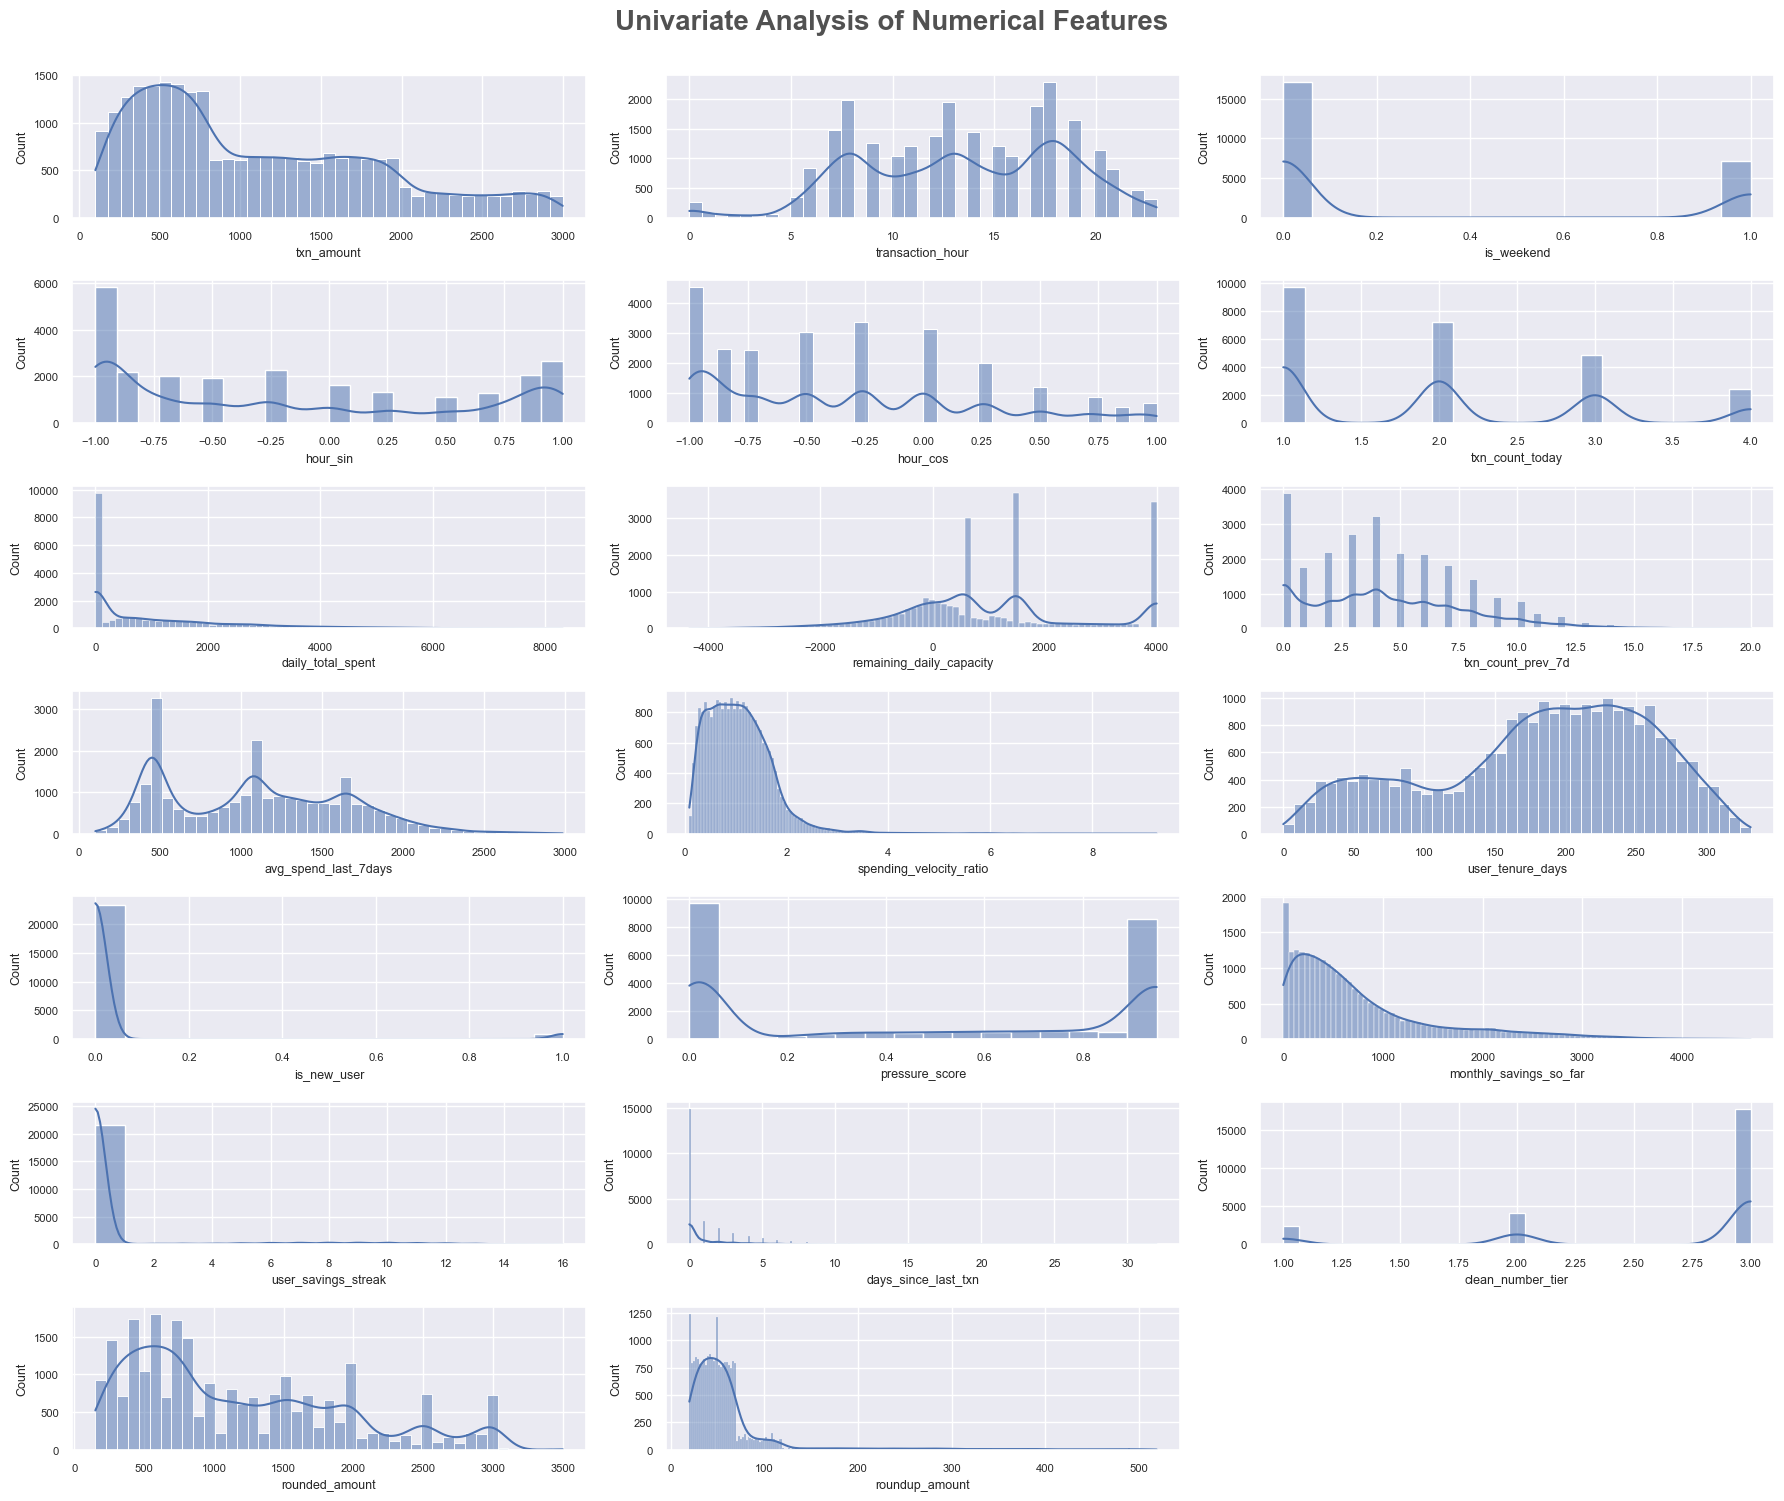

In [12]:
# Numerical Features
plt.figure(figsize=(18,15))
plt.suptitle('Univariate Analysis of Numerical Features', fontsize=20, fontweight='bold', alpha=0.8, y=1.)

for i in range(0, len(num_cols)):
    plt.subplot(7, 3, i+1)
    sns.histplot(x=df[num_cols[i]], kde=True)
    plt.xlabel(num_cols[i])

plt.tight_layout()

# save plot
plt.savefig('images/Univariate_Num.png', dpi=300, bbox_inches='tight')
plt.show()

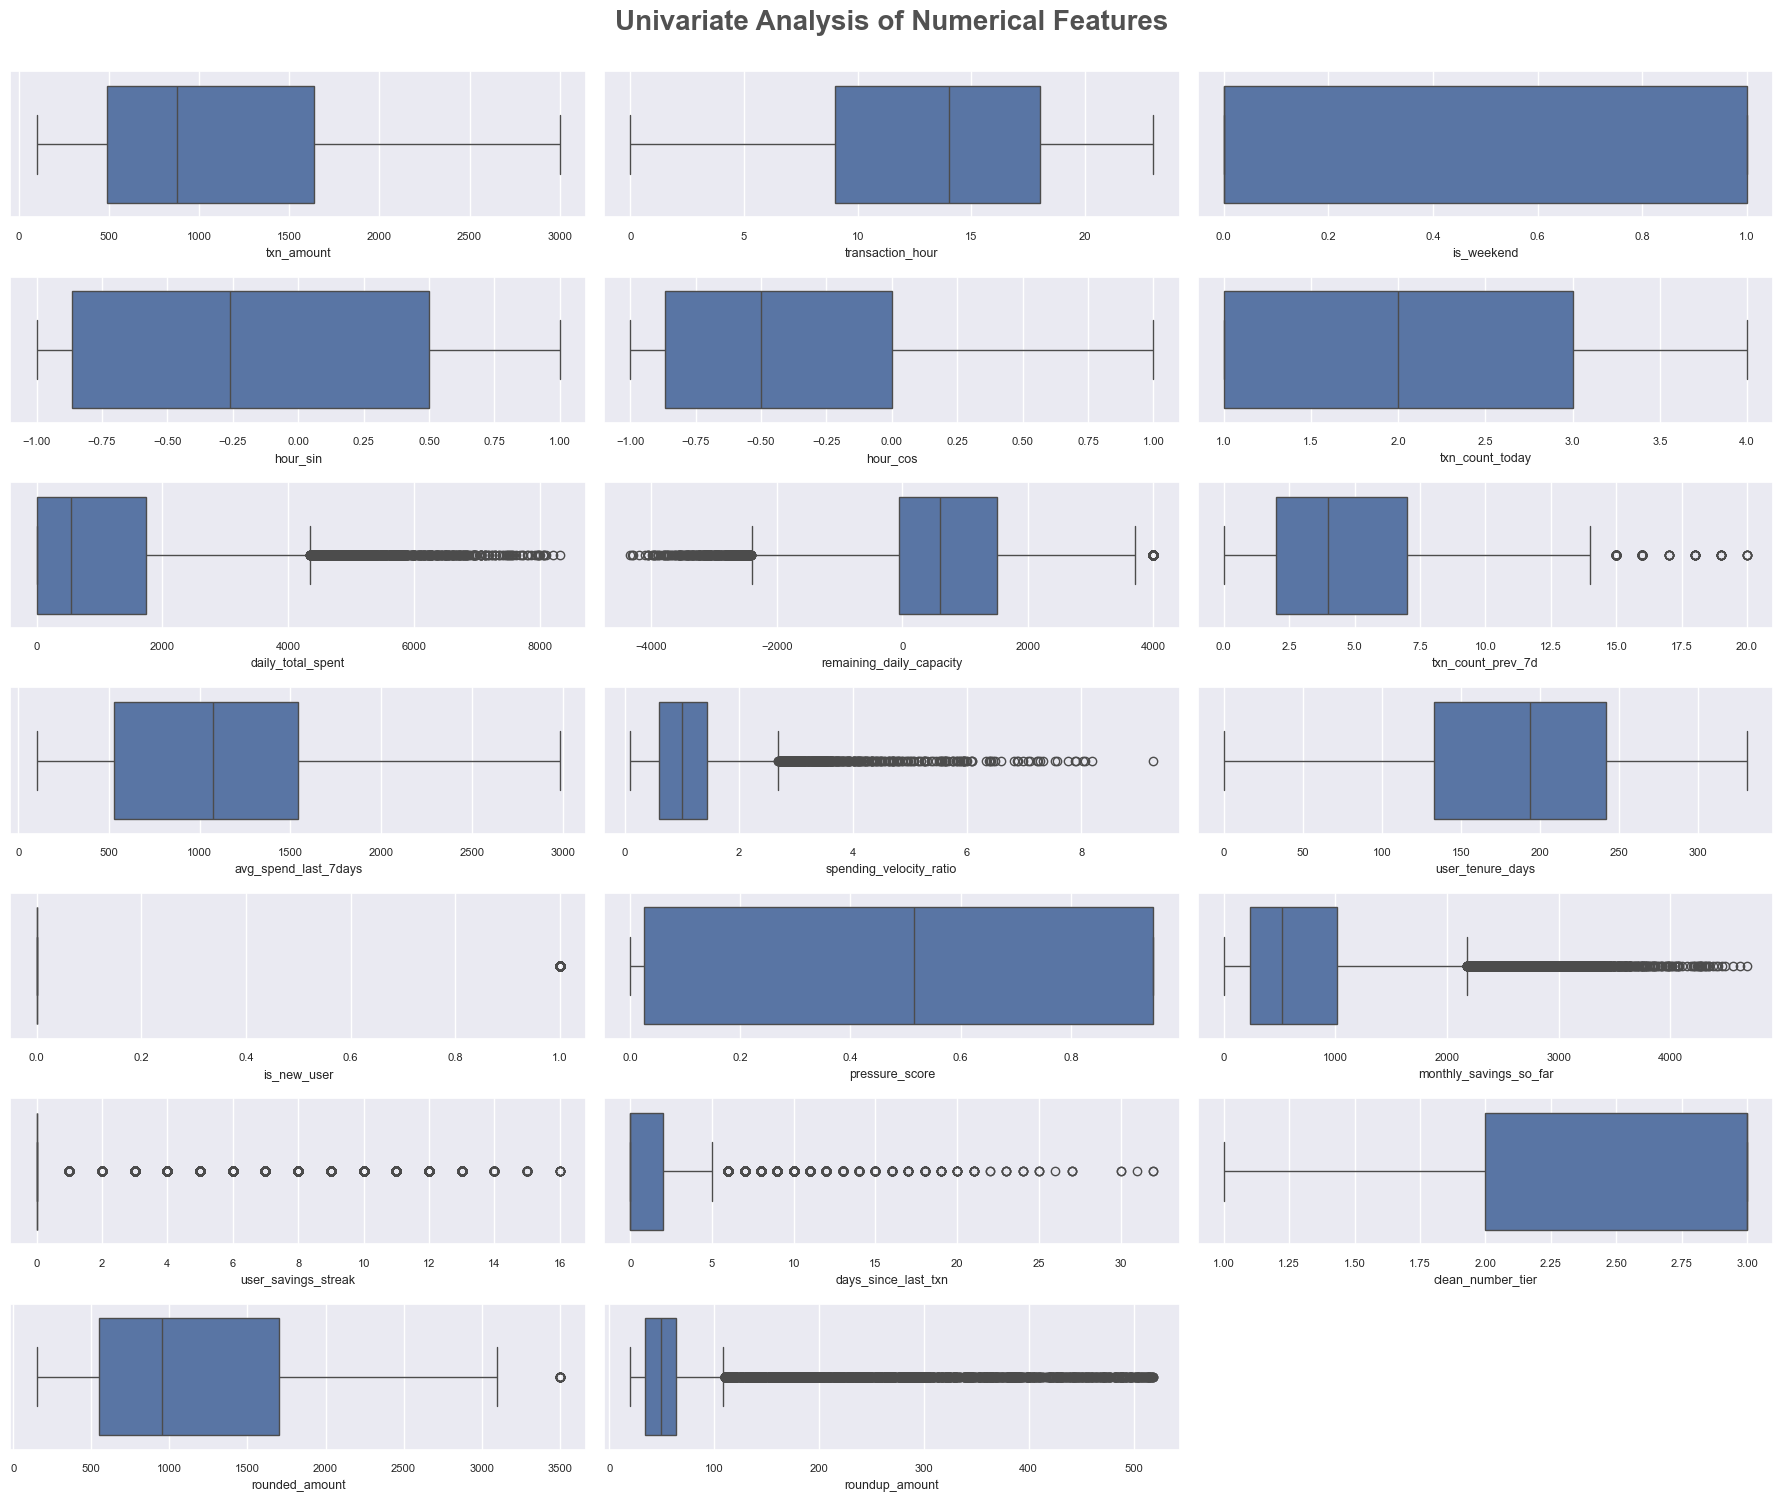

In [13]:
# outlier analysis - boxplot
plt.figure(figsize=(18,15))
plt.suptitle('Univariate Analysis of Numerical Features', fontsize=20, fontweight='bold', alpha=0.8, y=1.)

for i in range(0, len(num_cols)):
    plt.subplot(7, 3, i+1)
    sns.boxplot(x=df[num_cols[i]],)
    plt.xlabel(num_cols[i])

plt.tight_layout()

# save plot
plt.savefig('images/Univariate_Boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

### Key Takeaways — Numerical Features

- **Spending features** are heavily **right-skewed** → apply log transform, handle outliers  
- **Transaction counts** are low (mostly 1–4) → discrete/count behavior  
- **New users are rare** → strong class imbalance  
- **Pressure score is bimodal** → distinct low vs high segments  
- **Spending velocity** has extreme outliers → log/clip needed  
- **Remaining capacity** includes negatives → overspending signal  
- **Recency (days_since_last_txn)** is highly skewed → strong recent activity signal  
- **Round-up amount** is small & skewed → needs scaling/log transform  
- **Temporal features (hour_sin/cos)** are well-encoded → no change needed  
- **User tenure** is fairly smooth → minor scaling sufficient  
- **Clean number tier** is discrete → treat as categorical/ordinal

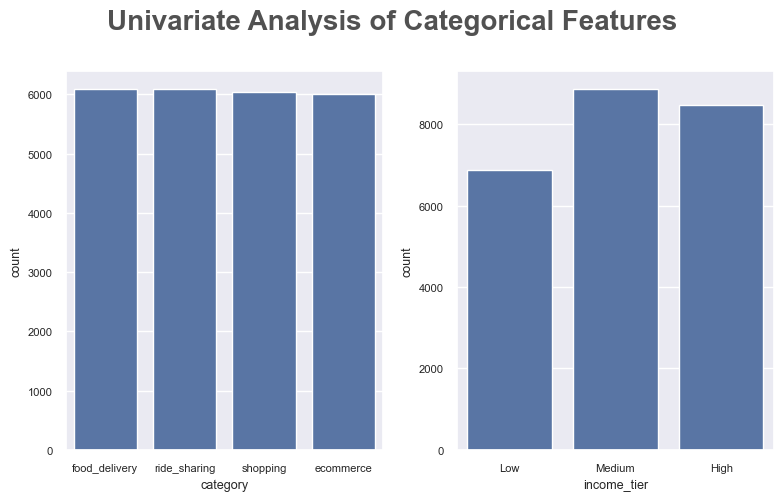

In [14]:
# categorical columns
cat_cols.remove('user_id')
cat_cols.remove('txn_id')
cat_cols.remove('timestamp')

plt.figure(figsize=(8, 5))
plt.suptitle('Univariate Analysis of Categorical Features', fontsize=20, fontweight='bold', alpha=0.8, y=1.)

for i in range(0, len(cat_cols)):
    plt.subplot(1, 2, i+1)
    sns.countplot(x=df[cat_cols[i]])
    plt.xlabel(cat_cols[i])

plt.tight_layout()

# save plot
plt.savefig('images/Univariate_Cat.png', dpi=300, bbox_inches='tight')
plt.show()

### Key Takeaways — Categorical Features

- **Transaction categories** are evenly distributed → no strong category dominance  
- **Income tiers** show moderate imbalance → more users in medium & high tiers  
- No severe skew → safe for standard encoding (one-hot or label)  
- Categories likely **weak standalone predictors** → better with interaction features  
- Consider combining with spending behavior for stronger signals  

---

### Bivariate Analysis — `roundup_amount` (target)

In [15]:
df.columns

Index(['txn_id', 'user_id', 'timestamp', 'txn_amount', 'category',
       'transaction_hour', 'is_weekend', 'hour_sin', 'hour_cos',
       'txn_count_today', 'daily_total_spent', 'remaining_daily_capacity',
       'txn_count_prev_7d', 'avg_spend_last_7days', 'spending_velocity_ratio',
       'income_tier', 'user_tenure_days', 'is_new_user', 'pressure_score',
       'monthly_savings_so_far', 'user_savings_streak', 'days_since_last_txn',
       'clean_number_tier', 'rounded_amount', 'roundup_amount'],
      dtype='object')

In [16]:
df.head(2)

,txn_id,user_id,timestamp,txn_amount,category,transaction_hour,is_weekend,hour_sin,hour_cos,txn_count_today,daily_total_spent,remaining_daily_capacity,txn_count_prev_7d,avg_spend_last_7days,spending_velocity_ratio,income_tier,user_tenure_days,is_new_user,pressure_score,monthly_savings_so_far,user_savings_streak,days_since_last_txn,clean_number_tier,rounded_amount,roundup_amount
0,TXN_00000001,USR_0001,2024-09-02 09:39:46,464,food_delivery,9,0,0.707,-0.707,1,0.000,600.000,0,450.000,1.031,Low,229,0,0.029,0,0,0,3,500,36
1,TXN_00000002,USR_0001,2024-09-02 13:53:43,460,ride_sharing,13,0,-0.259,-0.966,2,464.000,136.000,0,450.000,1.022,Low,229,0,0.888,36,0,0,3,500,40


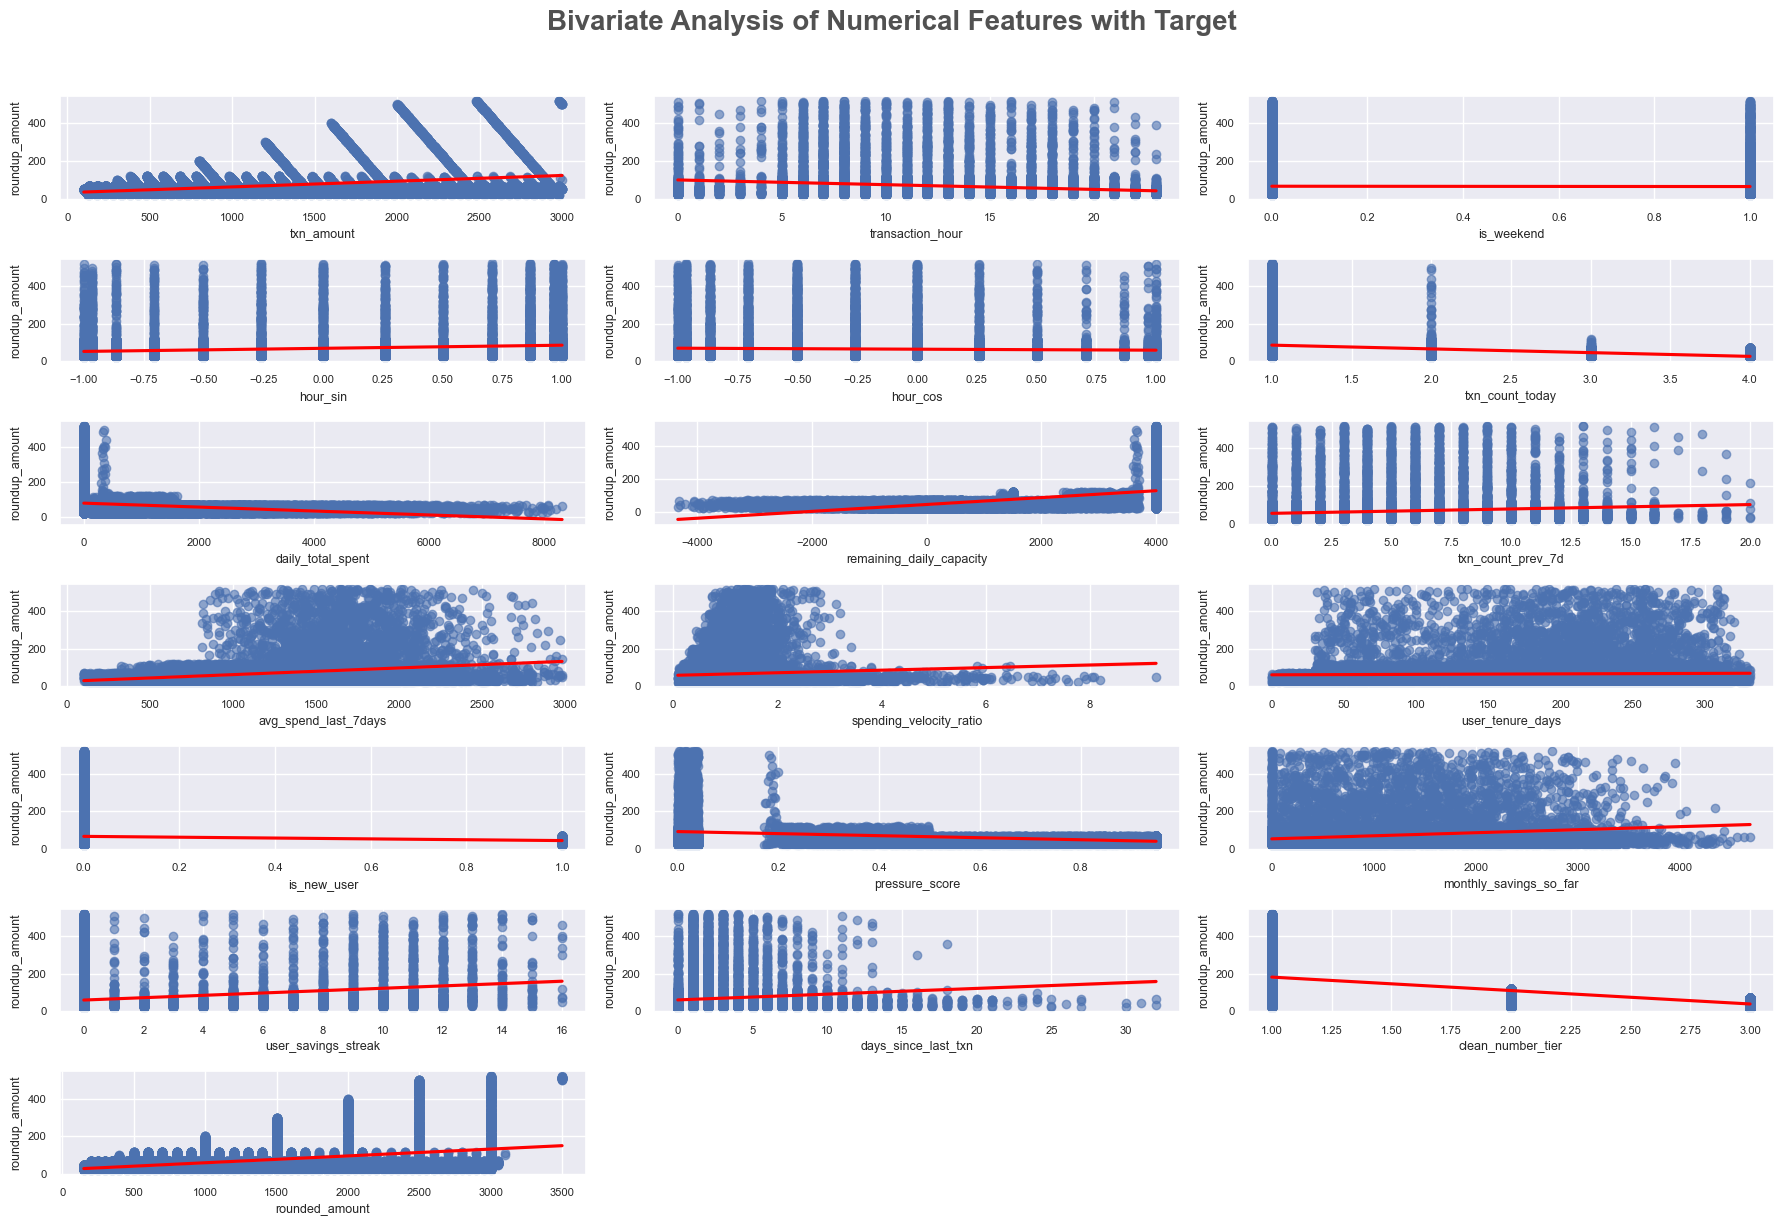

In [17]:
# Numerical Features
scatter_cols = [
      'txn_amount','transaction_hour', 'is_weekend', 'hour_sin', 'hour_cos',
      'txn_count_today', 'daily_total_spent', 'remaining_daily_capacity',
      'txn_count_prev_7d', 'avg_spend_last_7days', 'spending_velocity_ratio',
      'user_tenure_days', 'is_new_user', 'pressure_score',
      'monthly_savings_so_far', 'user_savings_streak', 'days_since_last_txn',
      'clean_number_tier', 'rounded_amount']

plt.figure(figsize=(18, 12))
plt.suptitle('Bivariate Analysis of Numerical Features with Target',
             fontsize=20, fontweight='bold', alpha=0.8, y=1.02)

for i, col in enumerate(scatter_cols):
    plt.subplot(7, 3, i+1)
    sns.regplot(x=df[col], y=df[TARGET_COL], scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
    plt.xlabel(col)
    plt.ylabel('roundup_amount')

plt.tight_layout()
plt.savefig('images/Scatter_Num.png', dpi=300, bbox_inches='tight')
plt.show()

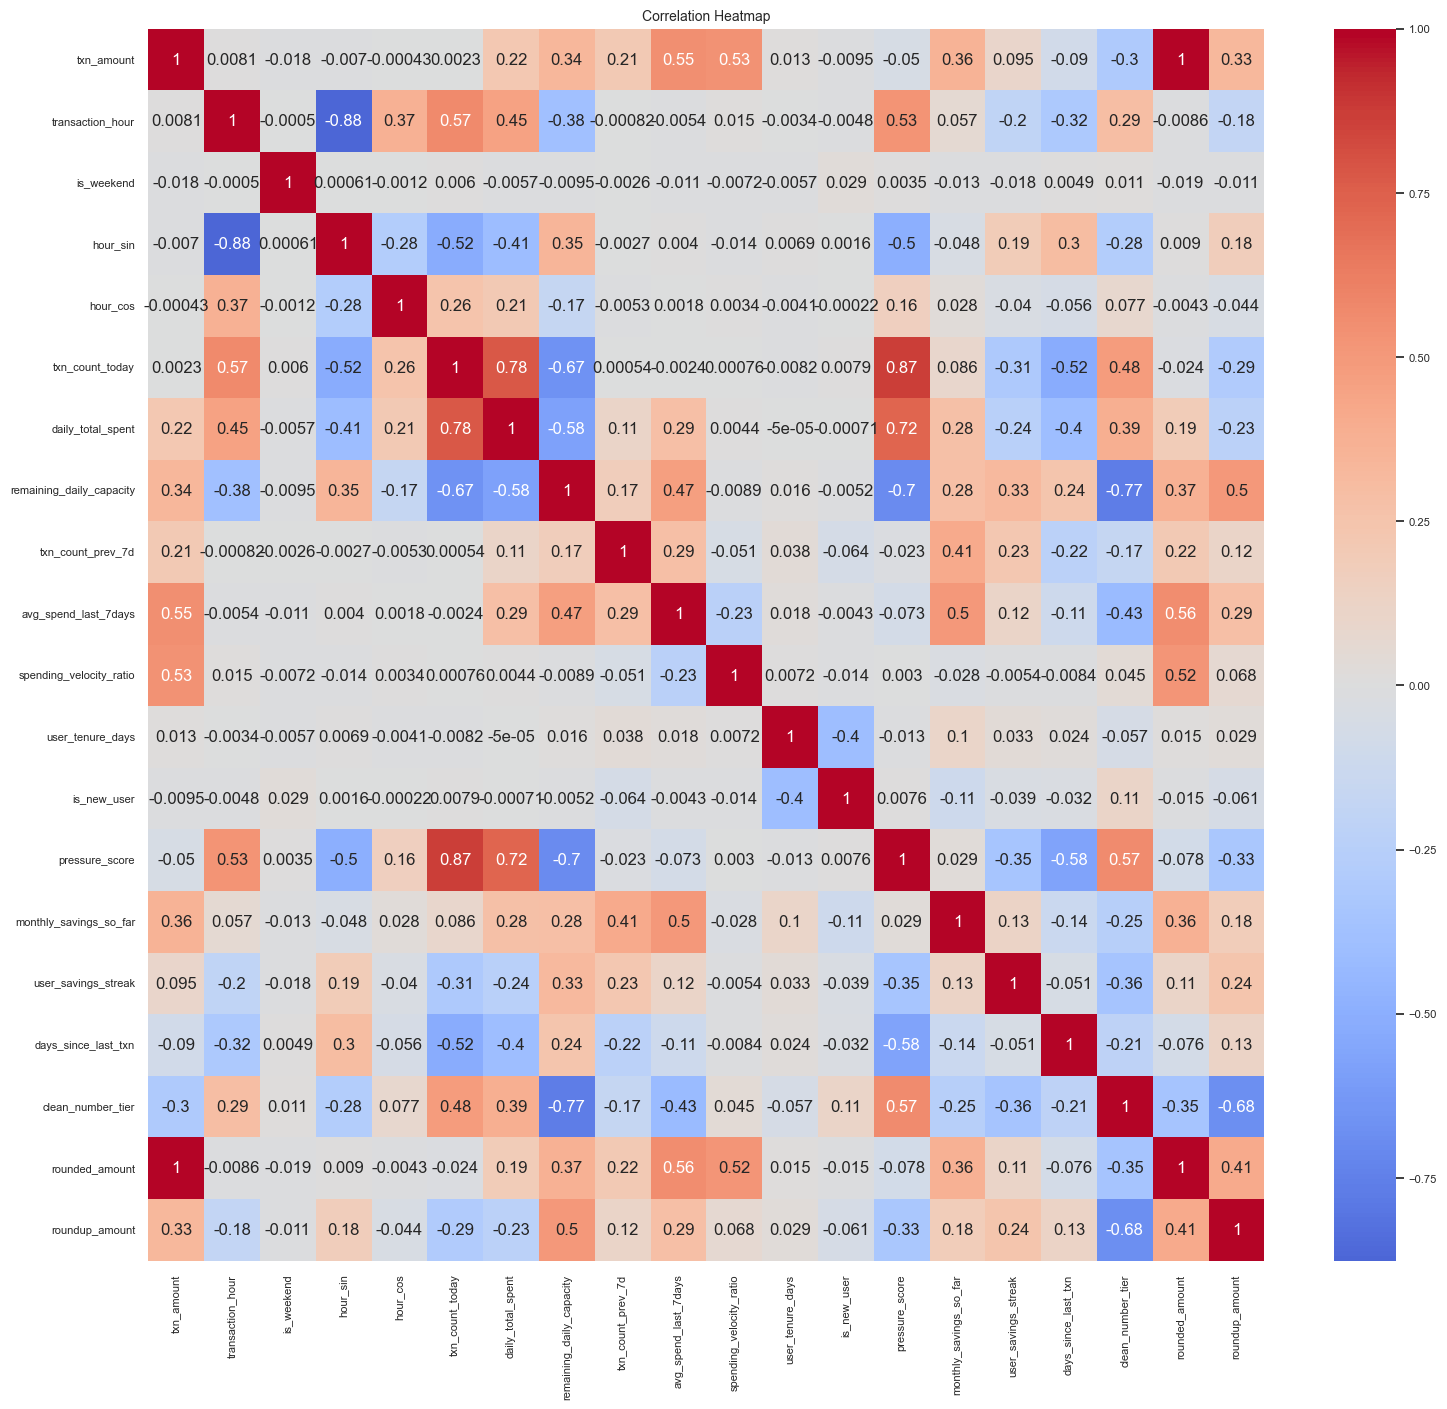

In [18]:
plt.figure(figsize=(18, 16))
sns.heatmap(
    df[num_cols].corr(),
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")
plt.savefig('images/Correlation.png', dpi=300, bbox_inches='tight')
plt.show()

In [19]:
# Correlation with target column
corr_with_target = df[num_cols].corr()[TARGET_COL].sort_values(ascending=False)
print("\nCorrelation with Taget")
print(corr_with_target)


Correlation with Taget
roundup_amount              1.000
remaining_daily_capacity    0.504
rounded_amount              0.409
txn_amount                  0.331
avg_spend_last_7days        0.287
user_savings_streak         0.243
monthly_savings_so_far      0.180
hour_sin                    0.178
days_since_last_txn         0.125
txn_count_prev_7d           0.115
spending_velocity_ratio     0.068
user_tenure_days            0.029
is_weekend                 -0.011
hour_cos                   -0.044
is_new_user                -0.061
transaction_hour           -0.184
daily_total_spent          -0.231
txn_count_today            -0.290
pressure_score             -0.331
clean_number_tier          -0.682
Name: roundup_amount, dtype: float64


### Key Takeaways

- **Strongest positive drivers**: `remaining_daily_capacity`, `rounded_amount`, and `txn_amount` — higher values lead to higher round-up.
- **Moderate influence**: Spending behavior features like `avg_spend_last_7days` and `user_savings_streak` show positive trends.
- **Weak impact features**: `spending_velocity_ratio`, `user_tenure_days`, and `is_weekend` contribute little to prediction.
- **Negative drivers**: `pressure_score`, `txn_count_today`, and `daily_total_spent` reduce round-up amounts.
- **Strong negative signal**: `clean_number_tier` has the highest negative correlation, indicating structured rounding behavior.
- **Time-related features** (`transaction_hour`, `hour_sin/cos`) show minor or mixed effects.
- Overall, **financial capacity and recent spending behavior dominate the prediction**, while temporal and user profile features have limited impact.

## Preprocessing & Evaluation

In [20]:
df.columns

Index(['txn_id', 'user_id', 'timestamp', 'txn_amount', 'category',
       'transaction_hour', 'is_weekend', 'hour_sin', 'hour_cos',
       'txn_count_today', 'daily_total_spent', 'remaining_daily_capacity',
       'txn_count_prev_7d', 'avg_spend_last_7days', 'spending_velocity_ratio',
       'income_tier', 'user_tenure_days', 'is_new_user', 'pressure_score',
       'monthly_savings_so_far', 'user_savings_streak', 'days_since_last_txn',
       'clean_number_tier', 'rounded_amount', 'roundup_amount'],
      dtype='object')

In [21]:
df = df.drop(columns=['user_id','txn_id','timestamp', 'rounded_amount'])

In [22]:
# Separate feature and target
X = df.drop(columns=['roundup_amount'])
y = df['roundup_amount']

In [23]:
X.head()

,txn_amount,category,transaction_hour,is_weekend,hour_sin,hour_cos,txn_count_today,daily_total_spent,remaining_daily_capacity,txn_count_prev_7d,avg_spend_last_7days,spending_velocity_ratio,income_tier,user_tenure_days,is_new_user,pressure_score,monthly_savings_so_far,user_savings_streak,days_since_last_txn,clean_number_tier
0,464,food_delivery,9,0,0.707,-0.707,1,0.000,600.000,0,450.000,1.031,Low,229,0,0.029,0,0,0,3
1,460,ride_sharing,13,0,-0.259,-0.966,2,464.000,136.000,0,450.000,1.022,Low,229,0,0.888,36,0,0,3
2,130,ride_sharing,18,0,-1.000,-0.000,3,924.000,-324.000,0,450.000,0.289,Low,229,0,0.950,76,0,0,3
3,360,shopping,8,1,0.866,-0.500,1,0.000,600.000,0,450.000,0.800,Low,241,0,0.009,96,0,12,3
4,692,ride_sharing,13,1,-0.259,-0.966,2,360.000,240.000,0,450.000,1.538,Low,241,0,0.710,136,0,0,3


In [24]:
y.head()

0    36
1    40
2    20
3    40
4    58
Name: roundup_amount, dtype: int64

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=RANDOM_STATE)

In [26]:
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (19377, 20)
Test shape: (4845, 20)


In [27]:
numerical_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_train.select_dtypes(include=['object']).columns.tolist()

print("Numerical features: ", numerical_features)
print("\nCategorical features: ", categorical_features)


# numerical features - preprocessing step
numerical_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

# categorical features - preprocessing step
categorical_transformer = Pipeline(
    steps=[
        ("onehot", OneHotEncoder(handle_unknown='ignore'))
    ]
)

# preprocessing pipeline
preprocess = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

Numerical features:  ['txn_amount', 'transaction_hour', 'is_weekend', 'hour_sin', 'hour_cos', 'txn_count_today', 'daily_total_spent', 'remaining_daily_capacity', 'txn_count_prev_7d', 'avg_spend_last_7days', 'spending_velocity_ratio', 'user_tenure_days', 'is_new_user', 'pressure_score', 'monthly_savings_so_far', 'user_savings_streak', 'days_since_last_txn', 'clean_number_tier']

Categorical features:  ['category', 'income_tier']


### Baseline Model

In [28]:
baseline_pipe = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", LinearRegression())
    ]
)

In [29]:
# preprocess data and train the baseline model
baseline_pipe.fit(X_train, y_train)

,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


### Baseline model evaluation

In [30]:
train_baseline_pred = baseline_pipe.predict(X_train)
test_baseline_pred = baseline_pipe.predict(X_test)

In [31]:
train_baseline_rmse = root_mean_squared_error(y_train, train_baseline_pred)
train_baseline_mae = mean_absolute_error(y_train, train_baseline_pred)
train_baseline_r2 = r2_score(y_train, train_baseline_pred)

print("\n===TRAIN BASELINE METRICS (LinearRegression)===")
print(f"RMSE: {train_baseline_rmse:.3f}")
print(f"MAE: {train_baseline_mae:.3f}")
print(f"R²: {train_baseline_r2:.3f}")


===TRAIN BASELINE METRICS (LinearRegression)===
RMSE: 48.301
MAE: 28.256
R²: 0.512


In [32]:
test_baseline_rmse = root_mean_squared_error(y_test, test_baseline_pred)
test_baseline_mae = mean_absolute_error(y_test, test_baseline_pred)
test_baseline_r2 = r2_score(y_test, test_baseline_pred)

print("\n===TEST BASELINE METRICS (LinearRegression)===")
print(f"RMSE: {test_baseline_rmse:.3f}")
print(f"MAE: {test_baseline_mae:.3f}")
print(f"R²: {test_baseline_r2:.3f}")


===TEST BASELINE METRICS (LinearRegression)===
RMSE: 46.855
MAE: 28.023
R²: 0.482


## Model selection & Optimization

In [33]:
# models to try
models = {
    "LinearRegression": LinearRegression(),

    "Ridge": Ridge(random_state=RANDOM_STATE),

    "Lasso": Lasso(random_state=RANDOM_STATE, max_iter=5000),

    "SVR": SVR(kernel='rbf', C=1.0, epsilon=0.1),

    "KNN": KNeighborsRegressor(n_neighbors=5),

    "RandomForest": RandomForestRegressor(
        n_estimators=200,
        max_depth=None,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "HistGB": HistGradientBoostingRegressor(
        max_iter=200,
        learning_rate=0.05,
        random_state=RANDOM_STATE
    ),

    "AdaBoost": AdaBoostRegressor(
        n_estimators=200,
        learning_rate=0.05,
        random_state=RANDOM_STATE
    ),

    "XGBoost": XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
}

In [34]:
k = 5
cv = KFold(n_splits=k, shuffle=True, random_state=RANDOM_STATE)

In [35]:
scoring = {
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error",
    "r2": "r2"
}

In [36]:
rows = []

for name, model in models.items():
    pipe = Pipeline(
        steps=[
            ("preprocess", preprocess),
            ("model", model)
        ]
    )
    scores = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=1)
    rows.append({
        "model": name,
        "cv_rmse": -scores["test_rmse"].mean(),
        "cv_mae": -scores["test_mae"].mean(),
        "cv_r2": scores["test_r2"].mean(),
    })

# sort based on the lowest rmse
cv_results = pd.DataFrame(rows).sort_values("cv_rmse")
print("====CV Model Comparison====")
print(cv_results)

====CV Model Comparison====
              model  cv_rmse  cv_mae  cv_r2
5      RandomForest    6.338   2.124  0.991
8           XGBoost   17.227   9.204  0.936
6            HistGB   17.992  10.285  0.931
7          AdaBoost   39.459  22.651  0.674
4               KNN   47.146  25.450  0.534
1             Ridge   48.365  28.303  0.510
0  LinearRegression   48.365  28.304  0.510
2             Lasso   48.711  27.608  0.503
3               SVR   52.017  25.422  0.434


In [37]:
best_row = cv_results.sort_values("cv_rmse").iloc[0]

best_model_name = best_row["model"]
best_rmse = best_row["cv_rmse"]

print("Best model based on CV RMSE:")
print("Model:", best_model_name)
print("CV RMSE:", best_rmse)

Best model based on CV RMSE:
Model: RandomForest
CV RMSE: 6.338227412763068


### Best Model: RandomForestRegressor

---

### Hyperparameter tuning

In [38]:
model_pipe = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", RandomForestRegressor(random_state=RANDOM_STATE))
    ]
)

In [39]:
param_space = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [None, 10, 20, 30],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__max_features': ['sqrt', 'log2', None],
    'model__n_jobs': [-1]
}

In [40]:
rs = RandomizedSearchCV(
    estimator=model_pipe,
    param_distributions=param_space,
    n_iter=15,
    cv=3,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=2
)

In [41]:
# perform random search
rs.fit(X_train, y_train)

Fitting 3 folds for each of 15 candidates, totalling 45 fits


,estimator,Pipeline(step...m_state=42))])
,param_distributions,"{'model__max_depth': [None, 10, ...], 'model__max_features': ['sqrt', 'log2', ...], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...], ...}"
,n_iter,15
,scoring,'neg_root_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [42]:
print("===TUNED RandomForestRegressor CV====")
print("Best CV RMSE:", -rs.best_score_)
print("Best params:", rs.best_params_)

===TUNED RandomForestRegressor CV====
Best CV RMSE: 11.633909754680138
Best params: {'model__n_jobs': -1, 'model__n_estimators': 200, 'model__min_samples_split': 2, 'model__min_samples_leaf': 2, 'model__max_features': None, 'model__max_depth': 20}


## Retraining with best params

In [43]:
best_model_pipe = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", RandomForestRegressor(
            n_estimators=200,
            max_depth=20,
            min_samples_split=2,
            min_samples_leaf=2,
            max_features=None,
            n_jobs=-1,
            random_state=RANDOM_STATE
        ))
    ]
)

In [44]:
best_model_pipe.fit(X_train, y_train)

,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## Final Evaluation

In [45]:
train_final_pred = best_model_pipe.predict(X_train)

train_final_rmse = root_mean_squared_error(y_train, train_final_pred)
train_final_mae = mean_absolute_error(y_train, train_final_pred)
train_final_r2 = r2_score(y_train, train_final_pred)

print("\n===Final Model (RandomForestRegressor) Train Performance===")
print(f"RMSE: {train_final_rmse:.3f}")
print(f"MAE: {train_final_mae:.3f}")
print(f"R²: {train_final_r2:.3f}")


===Final Model (RandomForestRegressor) Train Performance===
RMSE: 11.398
MAE: 7.283
R²: 0.973


In [46]:
test_final_pred = best_model_pipe.predict(X_test)

test_final_rmse = root_mean_squared_error(y_test, test_final_pred)
test_final_mae = mean_absolute_error(y_test, test_final_pred)
test_final_r2 = r2_score(y_test, test_final_pred)

print("\n===Final Model (RandomForestRegressor) Test Performance===")
print(f"RMSE: {test_final_rmse:.3f}")
print(f"MAE: {test_final_mae:.3f}")
print(f"R²: {test_final_r2:.3f}")


===Final Model (RandomForestRegressor) Test Performance===
RMSE: 12.541
MAE: 7.442
R²: 0.963


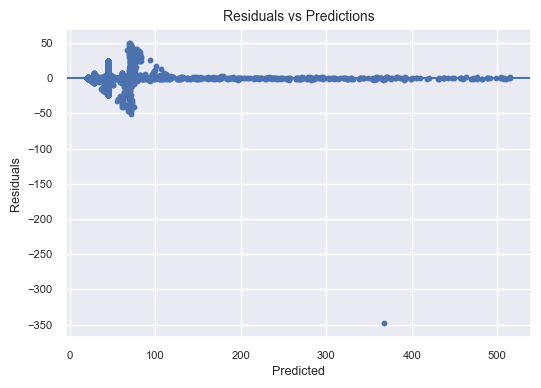

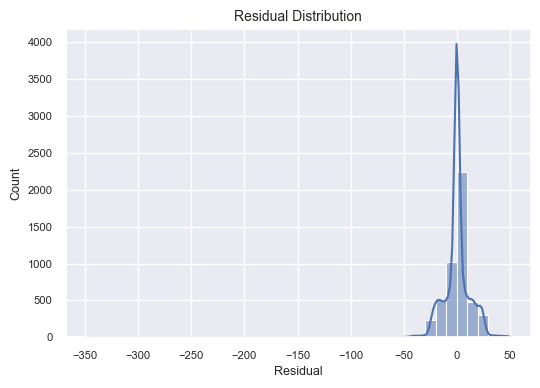

In [47]:
# residual plot
residuals = y_test - test_final_pred

plt.figure(figsize=(6, 4))
plt.scatter(test_final_pred, residuals, s=10)
plt.axhline(0)
plt.title("Residuals vs Predictions")
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.savefig('images/Residual Plot.png', dpi=300, bbox_inches='tight')
plt.show()

plt.figure(figsize=(6, 4))
sns.histplot(residuals, bins=40, kde=True)
plt.title("Residual Distribution")
plt.xlabel("Residual")
plt.ylabel("Count")
plt.savefig('images/Residual distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## Building a predictive system

In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24222 entries, 0 to 24221
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   txn_amount                24222 non-null  int64  
 1   category                  24222 non-null  object 
 2   transaction_hour          24222 non-null  int64  
 3   is_weekend                24222 non-null  int64  
 4   hour_sin                  24222 non-null  float64
 5   hour_cos                  24222 non-null  float64
 6   txn_count_today           24222 non-null  int64  
 7   daily_total_spent         24222 non-null  float64
 8   remaining_daily_capacity  24222 non-null  float64
 9   txn_count_prev_7d         24222 non-null  int64  
 10  avg_spend_last_7days      24222 non-null  float64
 11  spending_velocity_ratio   24222 non-null  float64
 12  income_tier               24222 non-null  object 
 13  user_tenure_days          24222 non-null  int64  
 14  is_new

In [49]:
def predict_roundup(
    model,
    txn_amount: int,
    category: str,
    transaction_hour: int,
    is_weekend: int,
    txn_count_today: int,
    daily_total_spent: float,
    txn_count_prev_7d: int,
    avg_spend_last_7days: float,
    income_tier: str,
    user_tenure_days: int,
    is_new_user: int,
    monthly_savings_so_far: int,
    user_savings_streak: int,
    days_since_last_txn: int,
    clean_number_tier: int
) -> float:

    hour_sin = np.sin(2 * np.pi * transaction_hour / 24)
    hour_cos = np.cos(2 * np.pi * transaction_hour / 24)

    remaining_daily_capacity = max(0, avg_spend_last_7days - daily_total_spent)

    spending_velocity_ratio = (
        txn_count_today / txn_count_prev_7d
        if txn_count_prev_7d > 0 else 0
    )

    pressure_score = (
        daily_total_spent / avg_spend_last_7days
        if avg_spend_last_7days > 0 else 0
    )

    new_row = pd.DataFrame([{
        "txn_amount": txn_amount,
        "category": category,
        "transaction_hour": transaction_hour,
        "is_weekend": is_weekend,
        "hour_sin": hour_sin,
        "hour_cos": hour_cos,
        "txn_count_today": txn_count_today,
        "daily_total_spent": daily_total_spent,
        "remaining_daily_capacity": remaining_daily_capacity,
        "txn_count_prev_7d": txn_count_prev_7d,
        "avg_spend_last_7days": avg_spend_last_7days,
        "spending_velocity_ratio": spending_velocity_ratio,
        "income_tier": income_tier,
        "user_tenure_days": user_tenure_days,
        "is_new_user": is_new_user,
        "pressure_score": pressure_score,
        "monthly_savings_so_far": monthly_savings_so_far,
        "user_savings_streak": user_savings_streak,
        "days_since_last_txn": days_since_last_txn,
        "clean_number_tier": clean_number_tier
    }])

    return float(model.predict(new_row)[0])

In [50]:
# Test Case 1: Low-income user, small transaction, early in the day, low daily spend
pred1 = predict_roundup(
    best_model_pipe,
    txn_amount=230,
    category="food_delivery",
    transaction_hour=8,
    is_weekend=0,
    txn_count_today=1,
    daily_total_spent=0.0,
    txn_count_prev_7d=3,
    avg_spend_last_7days=420.0,
    income_tier="Low",
    user_tenure_days=180,
    is_new_user=0,
    monthly_savings_so_far=150,
    user_savings_streak=0,
    days_since_last_txn=2,
    clean_number_tier=3
)
print("Test 1 - Low income, small txn, fresh day:", "Predicted Roundup:", pred1)

Test 1 - Low income, small txn, fresh day: Predicted Roundup: 20.0


In [51]:
# Test Case 2: High-income user, large transaction, evening, high daily total already spent
pred2 = predict_roundup(
    best_model_pipe,
    txn_amount=2150,
    category="ride_sharing",
    transaction_hour=19,
    is_weekend=1,
    txn_count_today=3,
    daily_total_spent=3850.0,
    txn_count_prev_7d=12,
    avg_spend_last_7days=1680.0,
    income_tier="High",
    user_tenure_days=290,
    is_new_user=0,
    monthly_savings_so_far=420,
    user_savings_streak=5,
    days_since_last_txn=0,
    clean_number_tier=1
)
print("Test 2 - High income, large txn, high daily spent:", "Predicted Roundup:", pred2)

Test 2 - High income, large txn, high daily spent: Predicted Roundup: 351.26190079365085


In [52]:
# Test Case 3: New user (is_new_user=1), medium txn, shopping category
pred3 = predict_roundup(
    best_model_pipe,
    txn_amount=680,
    category="shopping",
    transaction_hour=14,
    is_weekend=0,
    txn_count_today=2,
    daily_total_spent=450.0,
    txn_count_prev_7d=0,
    avg_spend_last_7days=0.0,
    income_tier="Medium",
    user_tenure_days=12,
    is_new_user=1,
    monthly_savings_so_far=0,
    user_savings_streak=0,
    days_since_last_txn=0,
    clean_number_tier=2
)
print("Test 3 - New user, shopping:", "Predicted Roundup:", pred3)

Test 3 - New user, shopping: Predicted Roundup: 21.87133145569122


In [53]:
# Test Case 4: Weekend evening food delivery, moderate daily spend, good savings streak
pred4 = predict_roundup(
    best_model_pipe,
    txn_amount=1240,
    category="food_delivery",
    transaction_hour=20,
    is_weekend=1,
    txn_count_today=4,
    daily_total_spent=1850.0,
    txn_count_prev_7d=15,
    avg_spend_last_7days=920.0,
    income_tier="Low",
    user_tenure_days=245,
    is_new_user=0,
    monthly_savings_so_far=680,
    user_savings_streak=8,
    days_since_last_txn=1,
    clean_number_tier=3
)
print("Test 4 - Weekend food delivery, savings streak:", "Predicted Roundup:", pred4)

Test 4 - Weekend food delivery, savings streak: Predicted Roundup: 44.222068725370136


In [54]:
# Test Case 5: Ecommerce, high velocity, near daily capacity, High income
pred5 = predict_roundup(
    best_model_pipe,
    txn_amount=2890,
    category="ecommerce",
    transaction_hour=16,
    is_weekend=0,
    txn_count_today=5,
    daily_total_spent=3720.0,
    txn_count_prev_7d=18,
    avg_spend_last_7days=1950.0,
    income_tier="High",
    user_tenure_days=310,
    is_new_user=0,
    monthly_savings_so_far=1250,
    user_savings_streak=12,
    days_since_last_txn=3,
    clean_number_tier=1
)
print("Test 5 - High velocity ecommerce, near capacity:", "Predicted Roundup:", pred5)

Test 5 - High velocity ecommerce, near capacity: Predicted Roundup: 109.08114285714286
